In [4]:
import pandas as pd
!pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/model_ready_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)
df.head()

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.3 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.3 MB 3.1 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 3.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.3 MB 3.1 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.3 MB 2.6 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.3 MB 2.2 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.3 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9

Matplotlib is building the font cache; this may take a moment.


(3936, 45)


,Date,NVDA_Open,NVDA_High,NVDA_Low,NVDA_Close,NVDA_Volume,SP500_Open,SP500_High,SP500_Low,SP500_Close,...,NVDA_EMA_12,NVDA_EMA_26,NVDA_MACD,NVDA_MACD_Signal,NVDA_Volatility_7,NVDA_Volatility_30,NVDA_Close_Lag_1,NVDA_Close_Lag_7,NVDA_Close_Lag_30,Target_Next_Close
0,2010-05-12,0.331948,0.337900,0.329887,0.336068,9.012360e+08,1155.430054,1172.869995,1155.430054,1171.670044,...,0.344567,0.361494,-0.016927,-0.013719,0.030320,0.023612,0.329658,0.355756,0.403602,0.335382
1,2010-05-13,0.334695,0.350033,0.332177,0.335382,1.252000e+09,1170.040039,1173.569946,1156.140015,1157.439941,...,0.343154,0.359560,-0.016406,-0.014256,0.023620,0.023581,0.336068,0.337671,0.398337,0.296693
2,2010-05-14,0.312718,0.313633,0.288451,0.296693,2.493068e+09,1157.189941,1157.189941,1126.140015,1135.680054,...,0.336006,0.354903,-0.018897,-0.015184,0.049732,0.030970,0.335382,0.331948,0.394216,0.297379
3,2010-05-17,0.297150,0.301042,0.287993,0.297379,8.560600e+08,1136.520020,1141.880005,1114.959961,1136.939941,...,0.330063,0.350642,-0.020579,-0.016263,0.050036,0.030715,0.296693,0.325080,0.400169,0.287535
4,2010-05-18,0.299897,0.301729,0.285933,0.287535,6.741120e+08,1138.780029,1148.660034,1117.199951,1120.800049,...,0.323520,0.345967,-0.022447,-0.017500,0.050698,0.030899,0.297379,0.319586,0.390325,0.292114


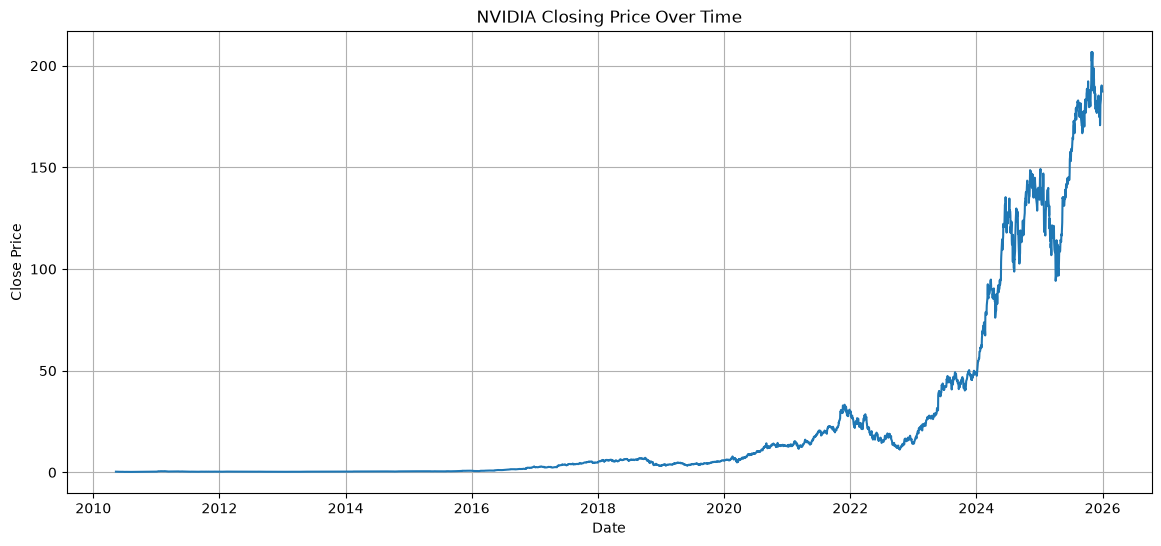

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["NVDA_Close"])
plt.title("NVIDIA Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

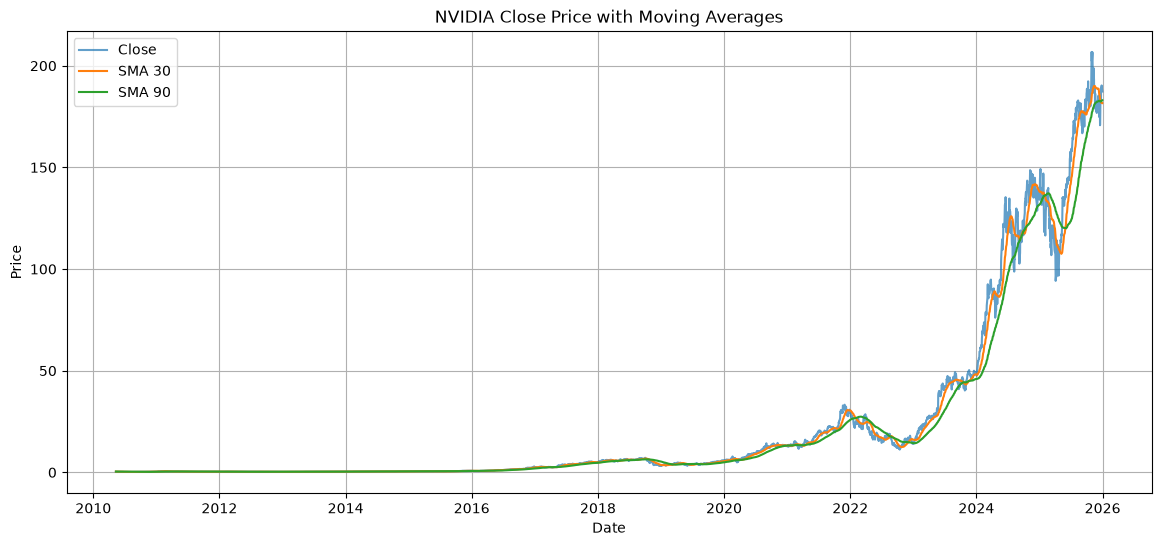

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["NVDA_Close"], label="Close", alpha=0.7)
plt.plot(df["Date"], df["NVDA_SMA_30"], label="SMA 30")
plt.plot(df["Date"], df["NVDA_SMA_90"], label="SMA 90")
plt.title("NVIDIA Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

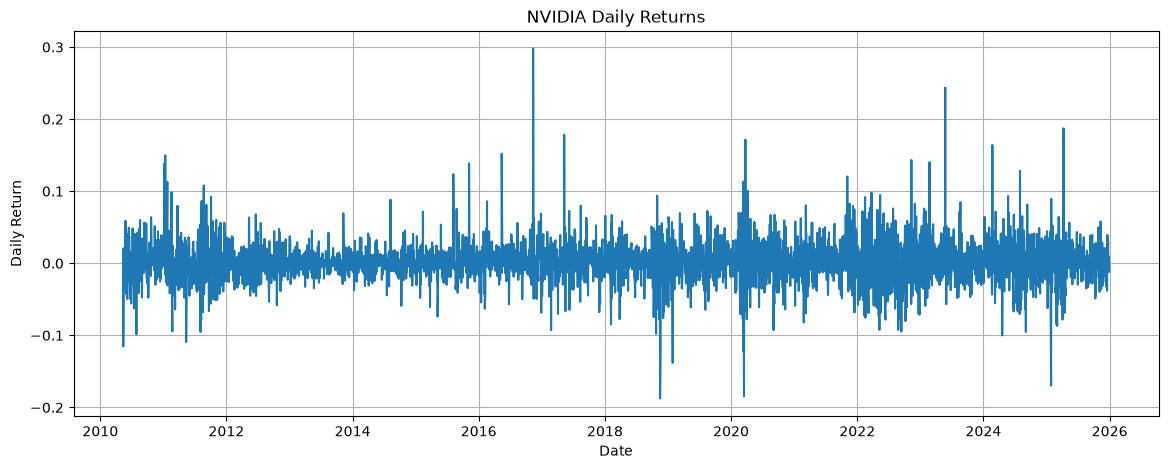

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["NVDA_Return"])
plt.title("NVIDIA Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

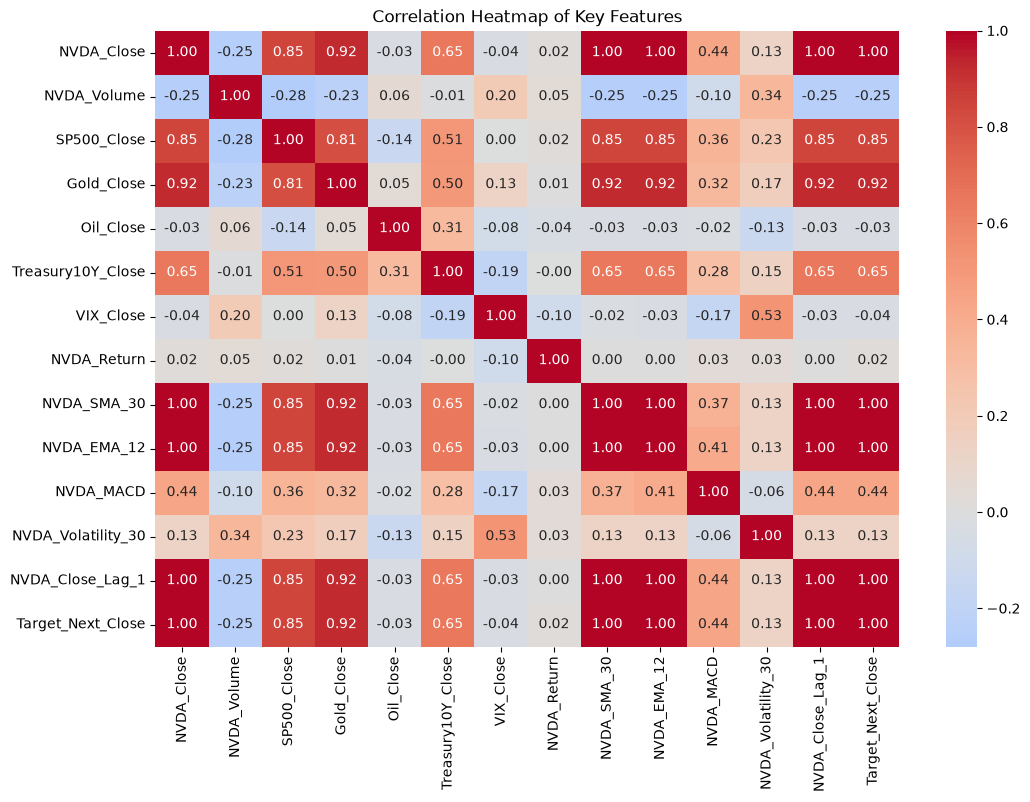

In [9]:
selected_cols = [
    "NVDA_Close",
    "NVDA_Volume",
    "SP500_Close",
    "Gold_Close",
    "Oil_Close",
    "Treasury10Y_Close",
    "VIX_Close",
    "NVDA_Return",
    "NVDA_SMA_30",
    "NVDA_EMA_12",
    "NVDA_MACD",
    "NVDA_Volatility_30",
    "NVDA_Close_Lag_1",
    "Target_Next_Close"
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[selected_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of Key Features")
plt.show()

In [10]:
correlations = numeric_df.corr()["Target_Next_Close"].sort_values(ascending=False)

print(correlations.head(15))
print(correlations.tail(15))

Target_Next_Close    1.000000
NVDA_Close           0.999471
NVDA_Low             0.999354
NVDA_High            0.999337
NVDA_Open            0.999190
NVDA_Close_Lag_1     0.999043
NVDA_SMA_7           0.998695
NVDA_EMA_12          0.998521
NVDA_EMA_26          0.997260
NVDA_Close_Lag_7     0.996564
NVDA_SMA_30          0.995978
NVDA_SMA_90          0.988932
NVDA_Close_Lag_30    0.987569
Gold_Low             0.922685
Gold_Close           0.922050
Name: Target_Next_Close, dtype: float64
NVDA_Volatility_7     0.093950
NVDA_Return           0.016178
Gold_Volume          -0.018730
VIX_High             -0.025417
VIX_Open             -0.032594
Oil_Low              -0.032671
Oil_Open             -0.033504
Oil_High             -0.033656
Oil_Close            -0.034155
VIX_Close            -0.035366
VIX_Low              -0.036781
Oil_Volume           -0.213193
NVDA_Volume          -0.254412
Treasury10Y_Volume         NaN
VIX_Volume                 NaN
Name: Target_Next_Close, dtype: float64
